## Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import iqr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## Load the data

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.conformal.pipeline import run_mondrian_regression

print("cwd:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

file_path = RESULTS_DIR / "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_predictions_embeddings.npz"

if not file_path.exists():
    raise FileNotFoundError(file_path)

print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("file_path:", file_path)
print("file exists:", file_path.exists())

data = np.load(file_path, allow_pickle=True)
print(data.files)

pred_cal = data["pred_cal"]
y_cal = data["y_cal"]
pred_test = data["pred_test"]
y_test = data["y_test"]

emb_cal = data["emb_cal"]
emb_test = data["emb_test"]

y_mean = data["y_mean"]
y_std = data["y_std"]

label_names = ["chirp_mass", "total_mass", "chi_eff"]

print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("pred_test:", pred_test.shape)
print("y_test:", y_test.shape)
print("emb_cal:", emb_cal.shape)
print("emb_test:", emb_test.shape)
print("y_mean:", y_mean)
print("y_std:", y_std)

cwd: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
PROJECT_ROOT: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe
RESULTS_DIR exists: True
file_path: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_predictions_embeddings.npz
file exists: True
['pred_train', 'pred_val', 'pred_cal', 'pred_test', 'y_train', 'y_val', 'y_cal', 'y_test', 'pred_train_phys', 'pred_val_phys', 'pred_cal_phys', 'pred_test_phys', 'y_train_phys', 'y_val_phys', 'y_cal_phys', 'y_test_phys', 'emb_train', 'emb_val', 'emb_cal', 'emb_test', 'idx_train', 'idx_val', 'idx_cal', 'idx_test', 'y_mean', 'y_std', 'label_names', 'best_epoch', 'best_val_loss', 'checkpoint_path']
pred_cal: (500, 3)
y_cal: (500, 3)
pred_test: (500, 3)
y_test: (500, 3)
emb_cal: (500, 32)
emb_test: (500, 32)
y_mean: [3.746003e+01 9.524749e+01 1.227917e-02]
y_std: [16.318987   34.057907    0.43827724]


## Reverse the standarization and get the physical labels

In [3]:
y_test_phys = y_test * y_std + y_mean

label_ranges_phys = {
    label: np.max(y_test_phys[:, j]) - np.min(y_test_phys[:, j])
    for j, label in enumerate(label_names)
}

label_ranges_phys

{'chirp_mass': np.float32(67.90154),
 'total_mass': np.float32(154.08817),
 'chi_eff': np.float32(1.9043859)}

## Some sanity checks

In [4]:
#Shapes sanity checks
assert pred_cal.ndim == 2
assert pred_test.ndim == 2
assert y_cal.ndim == 2
assert y_test.ndim == 2

assert pred_cal.shape == y_cal.shape
assert pred_test.shape == y_test.shape
assert pred_cal.shape[1] == len(label_names)
assert pred_test.shape[1] == len(label_names)

assert emb_cal.ndim == 2
assert emb_test.ndim == 2
assert emb_cal.shape[0] == pred_cal.shape[0]
assert emb_test.shape[0] == pred_test.shape[0]

assert y_mean.shape[0] == len(label_names)
assert y_std.shape[0] == len(label_names)
assert np.all(y_std > 0)

# Finite-value checks
for name, arr in {
    "pred_cal": pred_cal,
    "y_cal": y_cal,
    "pred_test": pred_test,
    "y_test": y_test,
    "emb_cal": emb_cal,
    "emb_test": emb_test,
    "y_mean": y_mean,
    "y_std": y_std,
}.items():
    assert np.all(np.isfinite(arr)), f"{name} contains NaN or inf"

print("All sanity checks passed.")

All sanity checks passed.


## Compute the metrics for Mondrian

In [5]:
confidence_level = 0.90

n_bins_grid = [4, 6, 8, 12, 16, 24]
taxonomy_modes = ["prediction", "difficulty"]
interval_modes = ["symmetric", "asymmetric"]

n_neighbors = 5
min_samples_per_bin = 10

rows = []
all_results = {}

for taxonomy_mode in taxonomy_modes:
    for interval_mode in interval_modes:
        for n_bins in n_bins_grid:

            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=confidence_level,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=min_samples_per_bin,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=n_neighbors,
                )

            result = run_mondrian_regression(**kwargs)
            all_results[(taxonomy_mode, interval_mode, n_bins)] = result

            metrics = result.metrics

            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                n_bad_bins_p005 = int(
                    np.nansum(metrics["bin_undercoverage_pvalue"][:, j] < 0.05)
                )

                row = {
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": n_bins,
                    "label": label,
                    "label_index": j,

                    "n_samples": int(metrics["n_samples_per_label"][j]),
                    "covered_count": int(metrics["covered_count_global"][j]),
                    
                    #Global coverage
                    "global_coverage": metrics["global_coverage"][j],
                    "miscoverage": metrics["miscoverage"][j],
                    "global_coverage_gap": metrics["global_coverage_gap"][j],
                    "global_undercoverage_pvalue": metrics["global_undercoverage_pvalue"][j],

                    #Global width
                    "global_mean_width_std": metrics["global_mean_width"][j],
                    "global_median_width_std": metrics["global_median_width"][j],

                    "global_mean_width_phys": np.mean(widths_phys[:, j]),
                    "global_median_width_phys": np.median(widths_phys[:, j]),
                    "global_iqr_width_phys": iqr(widths_phys[:, j]),

                    "normalized_median_width_range": (
                        np.median(widths_phys[:, j]) / label_ranges_phys[label]
                    ),
                    
                    # Bin-wise
                    "min_coverage_per_bin": metrics["min_coverage_per_label"][j],
                    "max_undercoverage_gap": metrics["max_undercoverage_gap"][j],

                    "min_count_per_bin": int(np.nanmin(metrics["counts_per_bin"][:, j])),
                    "max_count_per_bin": int(np.nanmax(metrics["counts_per_bin"][:, j])),

                    "n_bad_bins_p005": n_bad_bins_p005,
                    "bad_bin_fraction": n_bad_bins_p005 / n_bins,

                    "global_lower_miss_rate": metrics["global_lower_miss_rate"][j],
                    "global_upper_miss_rate": metrics["global_upper_miss_rate"][j],
                    "global_tail_miss_imbalance": metrics["global_tail_miss_imbalance"][j],
                }

                global_tol = metrics["global_tolerance_normal"]

                for k in [1, 2, 3]:
                    low = global_tol[f"{k}sigma_low"][j]
                    high = global_tol[f"{k}sigma_high"][j]
                    width = global_tol[f"{k}sigma_width"][j]

                    row[f"global_tol_{k}sigma_low"] = low
                    row[f"global_tol_{k}sigma_high"] = high
                    row[f"global_tol_{k}sigma_width"] = width
                    row[f"global_within_{k}sigma"] = (
                        low <= row["global_coverage"] <= high
                    )

                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(RESULTS_DIR / "summary_mondrian.csv", index=False)

display(summary_df)

/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 0. m=32, k_low=1, k_high=31. This usually means the bin has limited samples for equal-tailed calibration and the interval may be conservative.
  interval, indices = self._compute_asymmetric_interval(
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 1. m=31, k_low=1, k_high=30. This usually means the bin has limited samples for equal-tailed calibration and the interval may be conservative.
  interval, indices = self._compute_asymmetric_interval(
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 2. m=31, k_low=1, k_high=30. This usually means the bin has limited samples for equal-tailed calibrati

,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,prediction,symmetric,4,chirp_mass,0,500,435,0.870,0.130,0.030,0.017972,2.120421,2.475697,34.603121,40.400873,14.842123,0.594992,0.847222,0.052778,98,144,1,0.250000,0.076,0.054,0.022,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
1,prediction,symmetric,4,total_mass,1,500,446,0.892,0.108,0.008,0.295933,2.025138,2.065475,68.971979,70.345769,24.226528,0.456529,0.867647,0.032353,94,144,0,0.000000,0.040,0.068,0.028,0.886584,0.913416,0.013416,True,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
2,prediction,symmetric,4,chi_eff,2,500,460,0.920,0.080,0.020,0.944985,3.021170,2.983589,1.324110,1.307639,0.205713,0.686646,0.912000,0.000000,98,144,0,0.000000,0.052,0.028,0.024,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
3,prediction,symmetric,6,chirp_mass,0,500,447,0.894,0.106,0.006,0.348381,2.199452,2.517372,35.892830,41.080955,22.358924,0.605008,0.867647,0.032353,68,101,0,0.000000,0.060,0.046,0.014,0.886584,0.913416,0.013416,True,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
4,prediction,symmetric,6,total_mass,1,500,454,0.908,0.092,0.008,0.745311,2.106479,2.045407,71.742260,69.662269,17.620330,0.452094,0.867647,0.032353,68,101,0,0.000000,0.034,0.058,0.024,0.886584,0.913416,0.013416,True,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,difficulty,asymmetric,16,total_mass,1,500,453,0.906,0.094,0.006,0.693956,2.285273,2.172238,77.831627,73.981877,20.149602,0.480127,0.758621,0.141379,23,47,1,0.062500,0.062,0.032,0.030,0.886584,0.913416,0.013416,True,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
68,difficulty,asymmetric,16,chi_eff,2,500,468,0.936,0.064,0.036,0.998238,3.227295,3.184545,1.414450,1.395713,0.235961,0.732894,0.777778,0.122222,18,47,0,0.000000,0.036,0.028,0.008,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
69,difficulty,asymmetric,24,chirp_mass,0,500,434,0.868,0.132,0.032,0.012694,2.248996,2.403131,36.701341,39.216662,13.503091,0.577552,0.555556,0.344444,7,32,3,0.125000,0.090,0.042,0.048,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
70,difficulty,asymmetric,24,total_mass,1,500,435,0.870,0.130,0.030,0.017972,2.091741,2.058886,71.240323,70.121345,11.742140,0.455073,0.588235,0.311765,14,32,4,0.166667,0.082,0.048,0.034,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True


## Ranking Configurations

### Filtering the configurations

In [6]:
# 1. First we remove the configs that does not pass the pre-cut:
# within 2 sigma nominal CL, min counts per bin is 20 and fraction of bins with statisticall p<5% is less or equal 10 %
candidate_df = summary_df[
    (summary_df["global_within_2sigma"]) &
    (summary_df["min_count_per_bin"] >= 20) &
    (summary_df["bad_bin_fraction"] <= 0.10)
].copy()


# 2. For each label
#   - priorizes low width intervals
#   - and the ties are broken with the lower undercoverage per bin metric.
ranking_df = candidate_df.sort_values(
    ["label", "global_median_width_std", "max_undercoverage_gap"],
    ascending=[True, True, True],
)

ranking_df[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_within_1sigma",
        "global_within_2sigma",
        "global_undercoverage_pvalue",
        "min_coverage_per_bin",
        "max_undercoverage_gap",
        "n_bad_bins_p005",
        "bad_bin_fraction",
        "global_median_width_std",
        "global_median_width_phys",
        "normalized_median_width_range",
        "global_iqr_width_phys",
        "global_lower_miss_rate",
        "global_upper_miss_rate",
        "global_tail_miss_imbalance",
        "min_count_per_bin",
    ]
]


print("Summary configs:", summary_df.groupby("label").size())
print("Passed configs:", candidate_df.groupby("label").size())

Summary configs: label
chi_eff       24
chirp_mass    24
total_mass    24
dtype: int64
Passed configs: label
chi_eff        9
chirp_mass     8
total_mass    12
dtype: int64


### We see the best k configs per label

In [7]:
# best k configs for each label
top_k = 5

top_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(top_k)
)

# show only the following columns
top_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
65,chi_eff,difficulty,asymmetric,12,0.906,2.754166,1.207088,0.000000,0.076471,0.018
56,chi_eff,difficulty,asymmetric,4,0.920,2.879702,1.262108,0.000000,0.022137,0.004
5,chi_eff,prediction,symmetric,6,0.904,2.914118,1.277192,0.000000,0.055340,0.028
59,chi_eff,difficulty,asymmetric,6,0.912,2.921895,1.280600,0.000000,0.060494,0.016
62,chi_eff,difficulty,asymmetric,8,0.912,2.927293,1.282966,0.000000,0.047059,0.008
60,chirp_mass,difficulty,asymmetric,8,0.890,2.439632,39.812323,0.000000,0.075439,0.014
12,chirp_mass,prediction,symmetric,16,0.898,2.458576,40.121477,0.000000,0.114286,0.010
21,chirp_mass,prediction,asymmetric,6,0.880,2.462572,40.186688,0.000000,0.047059,0.020
27,chirp_mass,prediction,asymmetric,12,0.892,2.512011,40.993482,0.000000,0.087500,0.012
3,chirp_mass,prediction,symmetric,6,0.894,2.517372,41.080955,0.000000,0.032353,0.014


## Checking a configuration

In [8]:
def inspect_configuration(
    all_results,
    key,
    label_idx,
    label_names,
):
    result = all_results[key]
    metrics = result.metrics
    label = label_names[label_idx]

    print("Configuration:", key)
    print("Label:", label)

    print("\nCounts per bin:")
    print(metrics["counts_per_bin"][:, label_idx])

    print("\nCoverage per bin:")
    print(np.round(metrics["coverage_per_bin"][:, label_idx], 3))

    print("\nCovered count per bin:")
    print(metrics["covered_count_per_bin"][:, label_idx])

    print("\nBin undercoverage p-values:")
    print(np.round(metrics["bin_undercoverage_pvalue"][:, label_idx], 4))

    print("\nLower miss rate per bin:")
    print(np.round(metrics["lower_miss_rate_per_bin"][:, label_idx], 3))

    print("\nUpper miss rate per bin:")
    print(np.round(metrics["upper_miss_rate_per_bin"][:, label_idx], 3))

    print("\nInterval offsets per bin:")
    print(np.round(result.intervals[label_idx], 4))

    print("\nCalibrator bin counts:")
    print(result.calibrator.bin_counts_[label_idx])

    if hasattr(result.calibrator, "quantile_indices_"):
        print("\nQuantile indices:")
        print(result.calibrator.quantile_indices_[label_idx])

In [9]:
key = ("difficulty", "asymmetric", 12)
inspect_configuration(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
)

Configuration: ('difficulty', 'asymmetric', 12)
Label: chirp_mass

Counts per bin:
[43 38 19 35 49 55 38 40 38 47 50 48]

Coverage per bin:
[0.837 0.921 0.842 0.914 0.714 0.927 0.895 0.95  0.947 0.894 0.8   0.917]

Covered count per bin:
[36 35 16 32 35 51 34 38 36 42 40 44]

Bin undercoverage p-values:
[1.333e-01 7.463e-01 2.946e-01 6.937e-01 2.000e-04 8.130e-01 5.352e-01
 9.195e-01 9.047e-01 5.122e-01 2.450e-02 7.201e-01]

Lower miss rate per bin:
[0.07  0.026 0.158 0.057 0.122 0.073 0.053 0.05  0.053 0.106 0.2   0.042]

Upper miss rate per bin:
[0.093 0.053 0.    0.029 0.163 0.    0.053 0.    0.    0.    0.    0.042]

Interval offsets per bin:
[[-0.4884  0.4852]
 [-0.6607  1.1129]
 [-0.4783  0.8528]
 [-1.0026  1.3122]
 [-0.9463  0.8102]
 [-1.3984  1.5203]
 [-1.2342  1.2055]
 [-1.2289  1.6037]
 [-1.0218  1.4229]
 [-1.0276  1.401 ]
 [-0.6559  1.441 ]
 [-1.2378  1.4651]]

Calibrator bin counts:
[42 42 41 42 41 42 42 41 42 41 42 42]

Quantile indices:
[[ 2 40]
 [ 2 40]
 [ 2 39]
 [ 2 40]

## Plots

In [10]:
plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue",
}


def plot_global_coverage_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        if df_tax.empty:
            ax.set_title(f"{taxonomy_mode} (no data)")
            continue

        # Global tolerance is constant for this label.
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhspan(low_1, high_1, alpha=0.20, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, alpha=0.15, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, alpha=0.10, label=r"$3\sigma$")

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level * 100)}%",
        )

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Global coverage", fontsize=13)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper left",
        bbox_to_anchor=(0.82, 1.08),
        ncol=2,
    )

    plt.show()

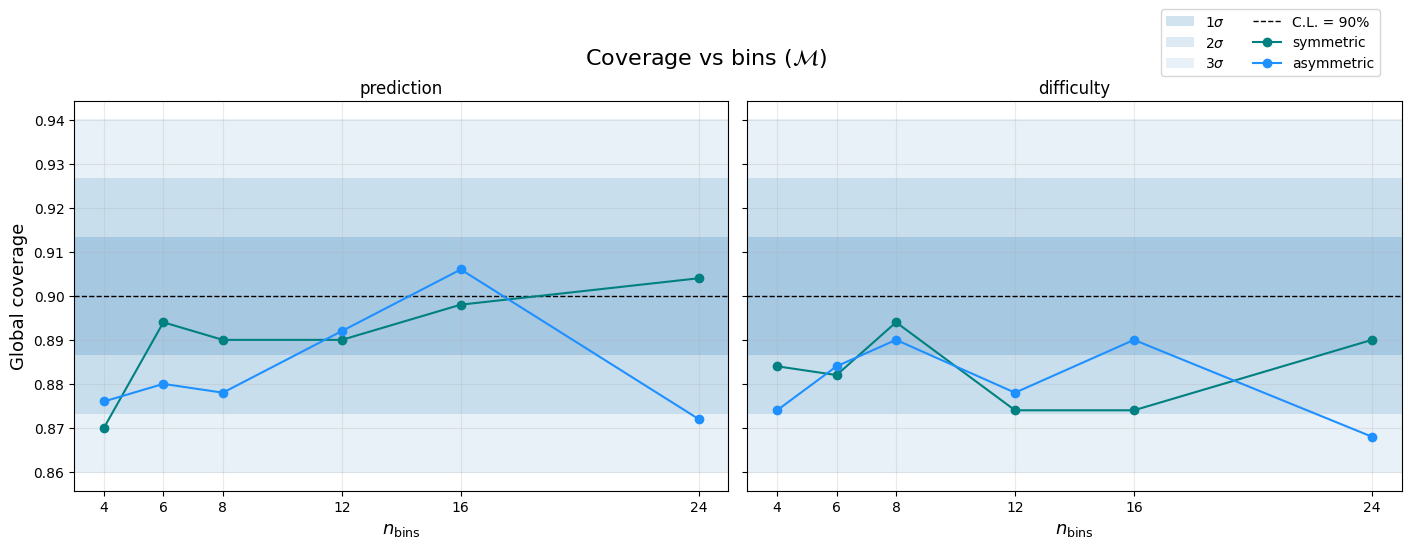

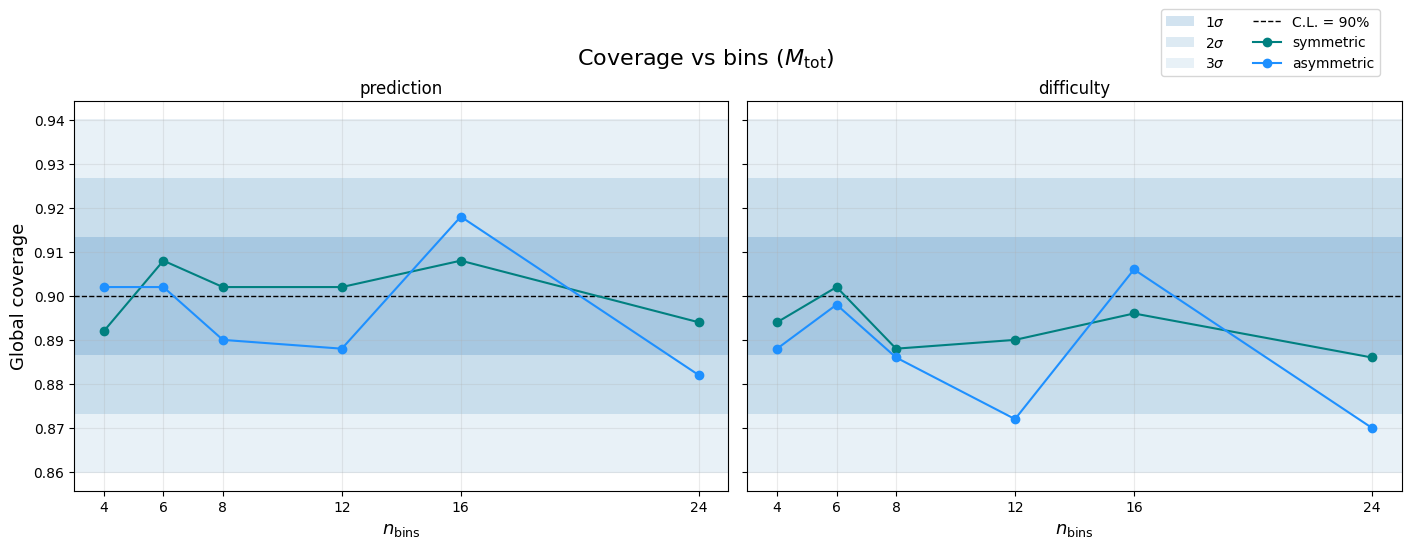

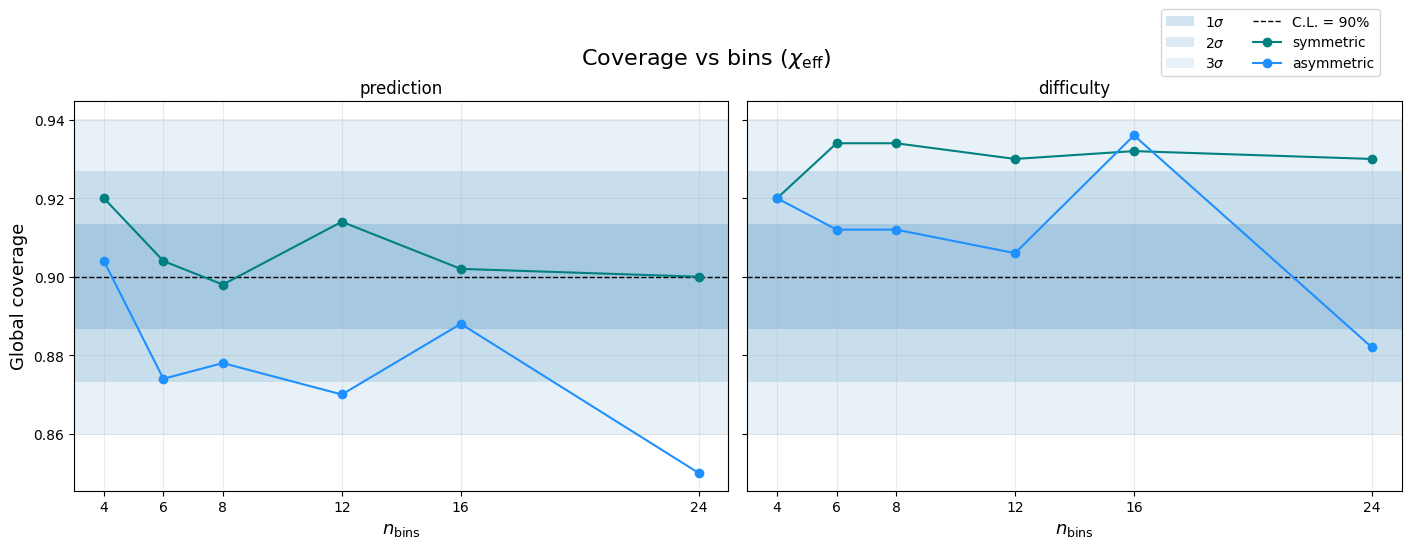

In [11]:
for label in label_names:
    plot_global_coverage_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        plot_colors=plot_colors,
    )

In [12]:
def plot_width_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    plot_labels,
    width_column="global_median_width_std",
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode[width_column],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_title(taxonomy_mode)
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(width_column, fontsize=13)
    fig.suptitle(f"Interval width vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=2,
    )

    plt.show()

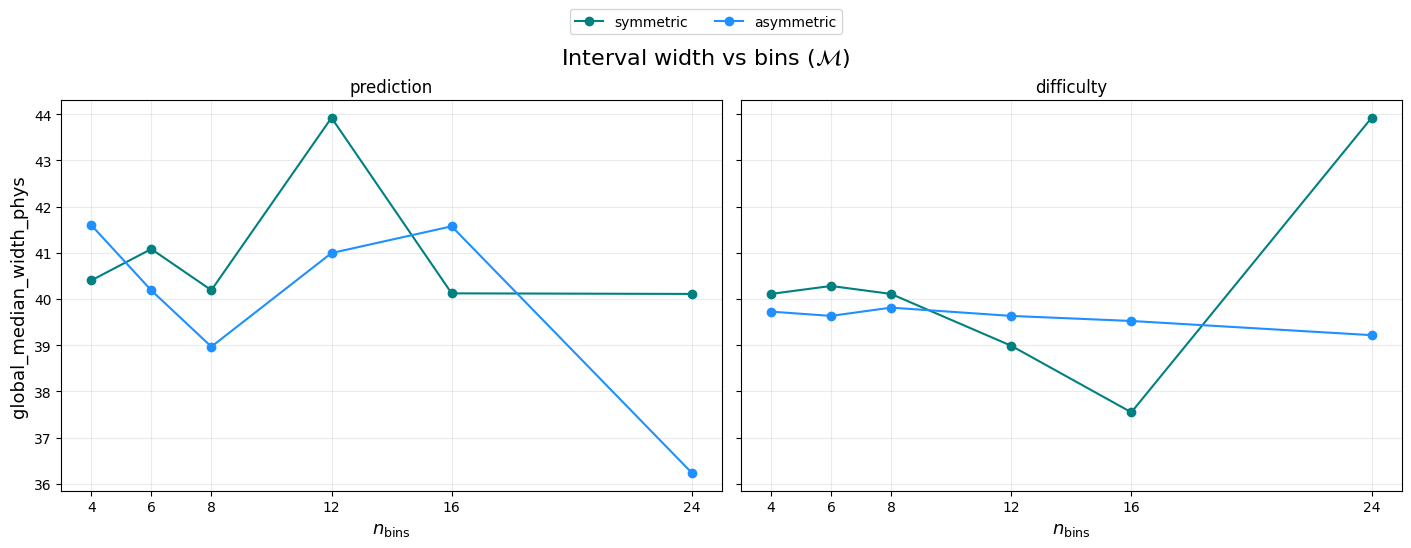

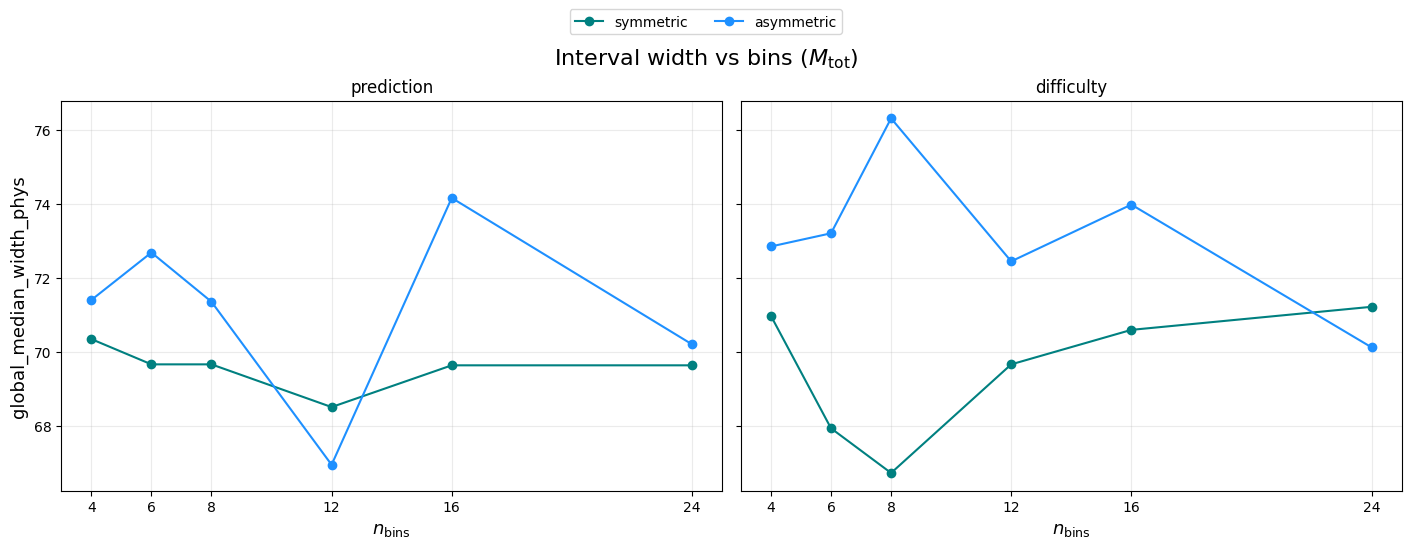

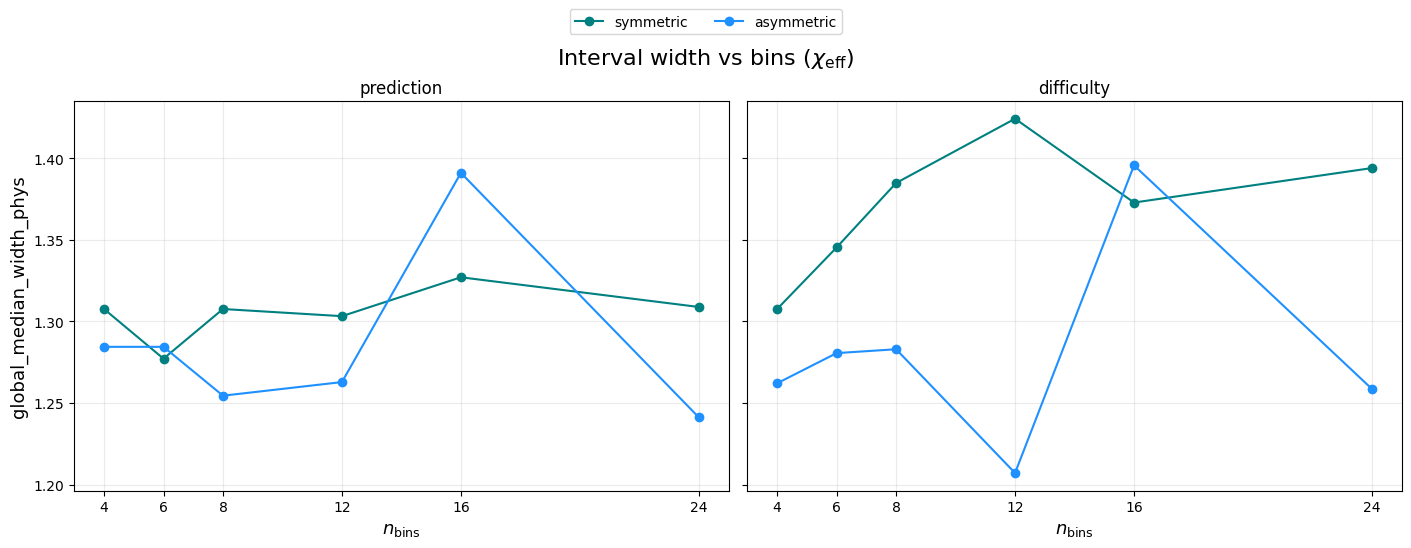

In [13]:
for label in label_names:
    plot_width_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
        plot_colors=plot_colors,
    )

In [14]:
def plot_coverage_width_tradeoff(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    width_column="global_median_width_std",
):
    df_label = summary_df[summary_df["label"] == label]

    scatter_color = {

    }

    plt.figure(figsize=(16, 10))

    for taxonomy_mode in taxonomy_modes:
        for interval_mode in interval_modes:
            df_mode = df_label[
                (df_label["taxonomy_mode"] == taxonomy_mode) &
                (df_label["interval_mode"] == interval_mode)
            ]

            plt.scatter(
                df_mode[width_column],
                df_mode["global_coverage"],
                s=350,
                label=f"{taxonomy_mode}-{interval_mode}",
            )

            for _, row in df_mode.iterrows():
                plt.text(
                    row[width_column],
                    row["global_coverage"],
                    str(row["n_bins"]),
                    fontsize=14,
                    ha="center",
                    va="center",
                    color="white",
                )

    plt.axhline(confidence_level, color="black", linestyle="--", linewidth=1)
    plt.xlabel(width_column)
    plt.ylabel("Global coverage")
    plt.title(f"Coverage-efficiency tradeoff ({plot_labels[label]})", fontsize=18)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=14)
    plt.show()

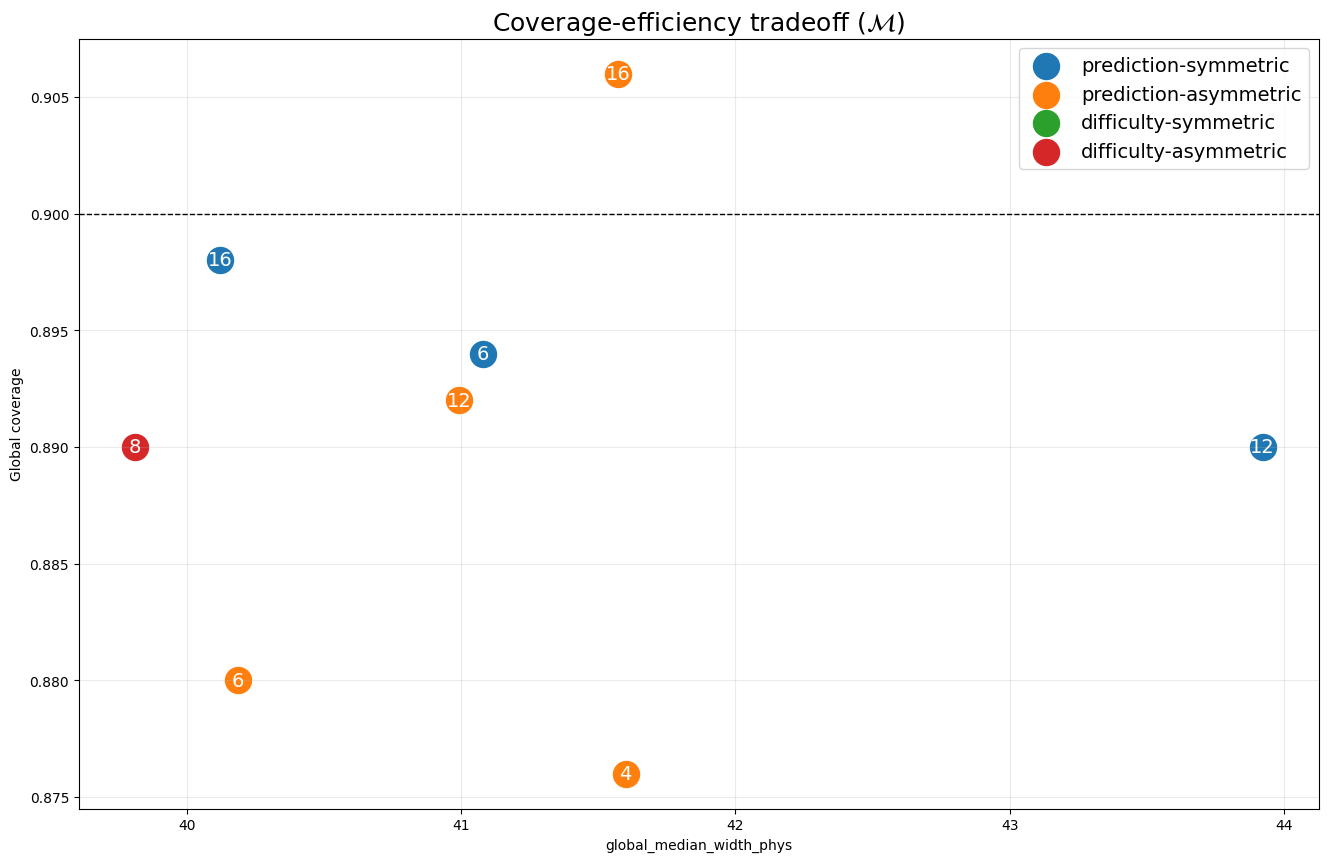

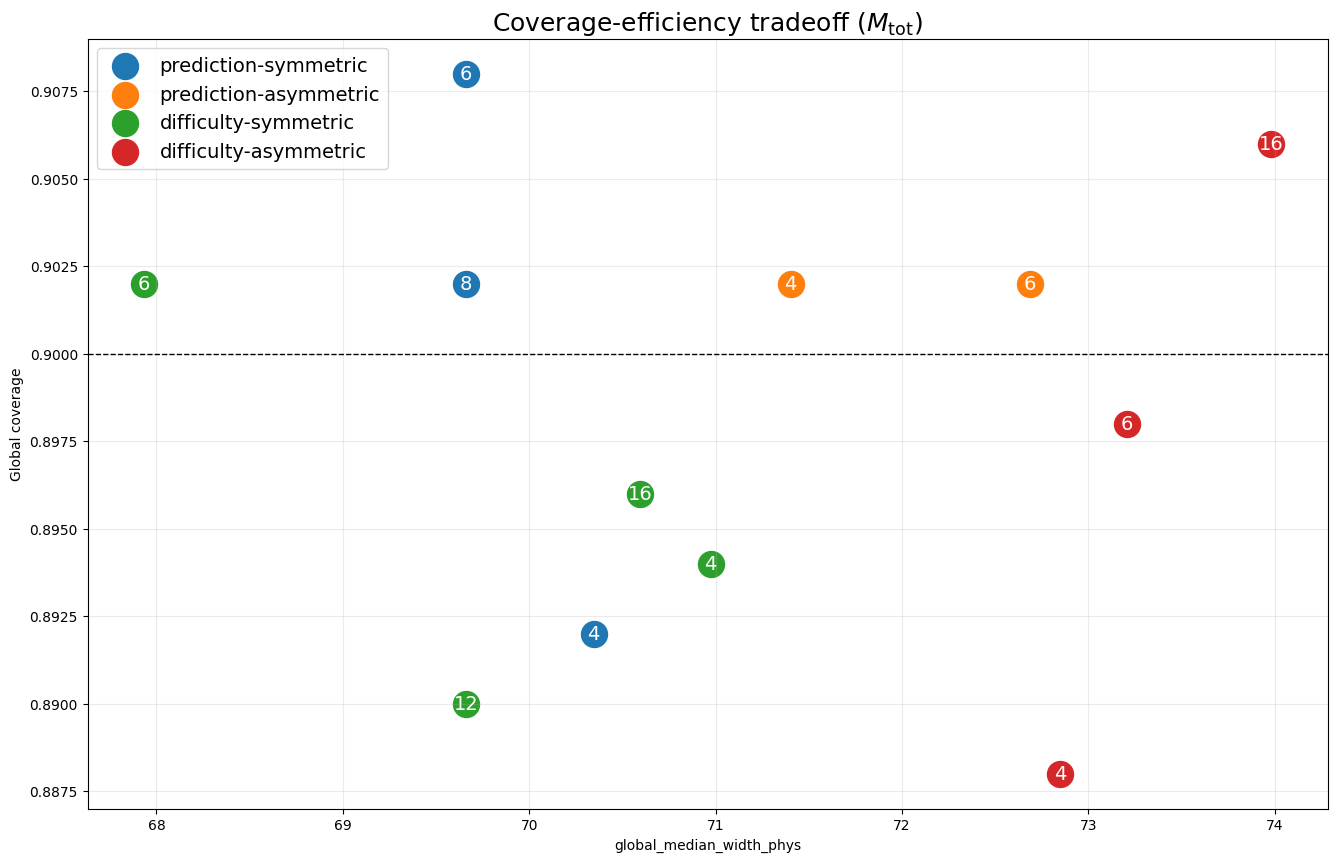

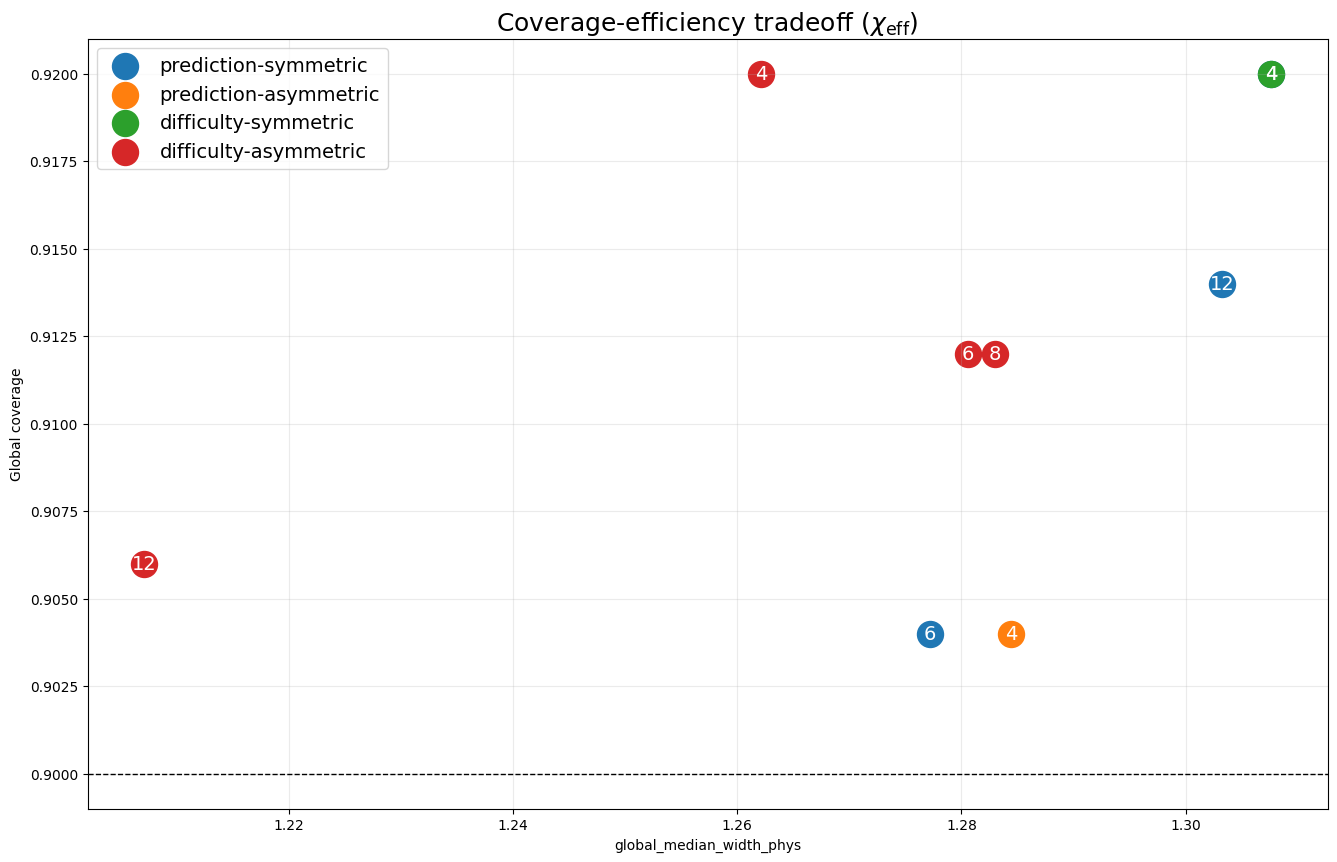

In [15]:
for label in label_names:
    plot_coverage_width_tradeoff(
        summary_df=candidate_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
    )

In [16]:
def plot_coverage_per_bin(
    all_results,
    key,
    label_idx,
    label_names,
    plot_labels,
    confidence_level,
):
    result = all_results[key]
    metrics = result.metrics

    label = label_names[label_idx]

    coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
    counts_per_bin = metrics["counts_per_bin"][:, label_idx]
    bin_tol = metrics["bin_tolerance_normal"]

    x = np.arange(len(coverage_per_bin))

    low_1 = bin_tol["1sigma_low"][:, label_idx]
    low_2 = bin_tol["2sigma_low"][:, label_idx]
    low_3 = bin_tol["3sigma_low"][:, label_idx]

    high_1 = bin_tol["1sigma_high"][:, label_idx]
    high_2 = bin_tol["2sigma_high"][:, label_idx]
    high_3 = bin_tol["3sigma_high"][:, label_idx]

    band_color = "tab:red"

    plt.figure(figsize=(9, 5))

    plt.fill_between(
        x, low_3, high_3,
        color=band_color,
        alpha=0.10,
        label=r"Nominal 3$\sigma$",
        zorder=1,
    )
    plt.fill_between(
        x, low_2, high_2,
        color=band_color,
        alpha=0.15,
        label=r"Nominal 2$\sigma$",
        zorder=2,
    )
    plt.fill_between(
        x, low_1, high_1,
        color=band_color,
        alpha=0.20,
        label=r"Nominal 1$\sigma$",
        zorder=3,
    )

    plt.plot(
        x,
        coverage_per_bin,
        marker="o",
        color="maroon",
        label="Empirical coverage",
        zorder=4,
    )

    plt.axhline(
        confidence_level,
        linestyle="--",
        alpha=0.5,
        linewidth=1.0,
        color="black",
        label=rf"C.L. = {confidence_level}",
    )

    for i, n in enumerate(counts_per_bin):
        plt.text(
            i,
            coverage_per_bin[i] - 0.03,
            str(n),
            ha="center",
            fontsize=10,
            color="k",
        )

    plt.xlabel("Bin index")
    plt.ylabel("Coverage")
    plt.title(f"Coverage per bin | {plot_labels[label]} | {key}")
    plt.ylim(0.65, 1.02)
    plt.legend(ncols=2, loc="lower right")
    plt.grid(alpha=0.25)
    plt.show()

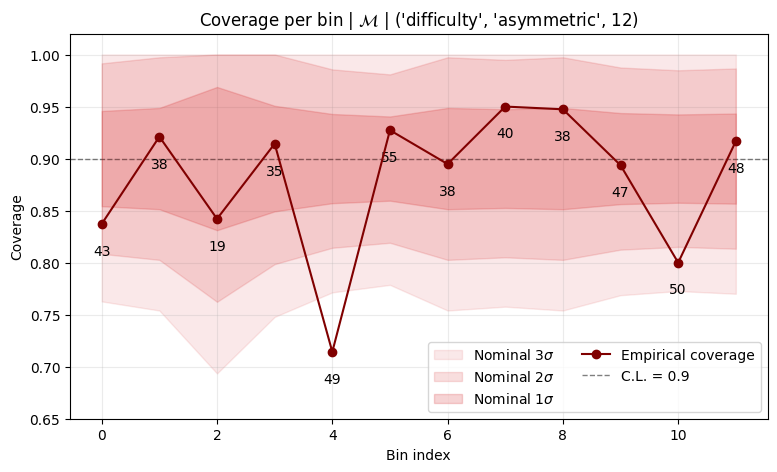

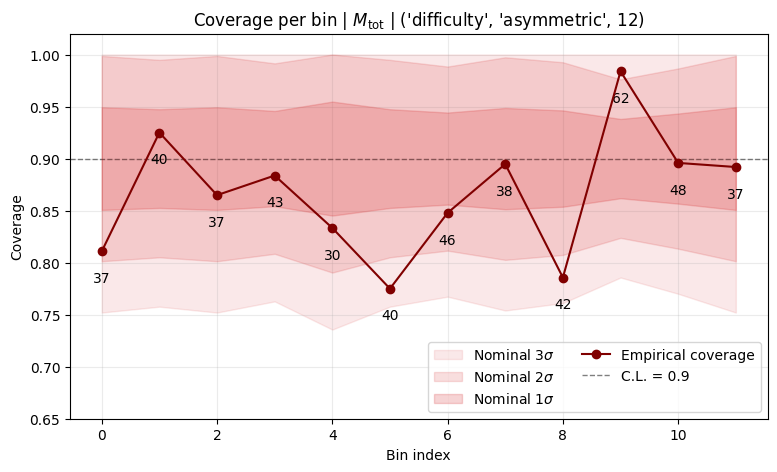

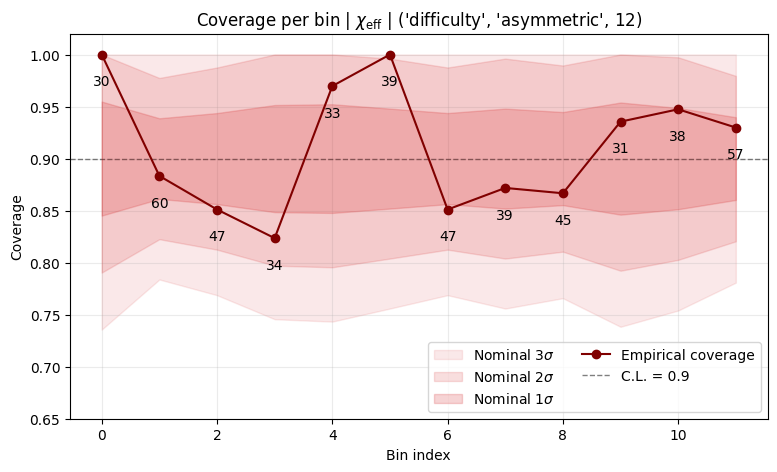

In [17]:
key = ("difficulty", "asymmetric", 12)

for label_idx in range(len(label_names)):
    plot_coverage_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=confidence_level,
    )

## Final candidate configuration

In [18]:
best_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(1)
)

best_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
65,chi_eff,difficulty,asymmetric,12,0.906,2.754166,1.207088,0.0,0.076471,0.018
60,chirp_mass,difficulty,asymmetric,8,0.890,2.439632,39.812323,0.0,0.075439,0.014
40,total_mass,difficulty,symmetric,6,0.902,1.994641,67.933308,0.0,0.037500,0.034


Configuration: ('difficulty', 'asymmetric', 12)
Label: chi_eff

Counts per bin:
[30 60 47 34 33 39 47 39 45 31 38 57]

Coverage per bin:
[1.    0.883 0.851 0.824 0.97  1.    0.851 0.872 0.867 0.935 0.947 0.93 ]

Covered count per bin:
[30 53 40 28 32 39 40 34 39 29 36 53]

Bin undercoverage p-values:
[1.     0.3935 0.1857 0.1185 0.9691 1.     0.1857 0.3504 0.2923 0.8304
 0.9047 0.8344]

Lower miss rate per bin:
[0.    0.033 0.021 0.176 0.03  0.    0.149 0.103 0.089 0.032 0.    0.035]

Upper miss rate per bin:
[0.    0.083 0.128 0.    0.    0.    0.    0.026 0.044 0.032 0.053 0.035]

Interval offsets per bin:
[[-1.6249  1.4735]
 [-1.371   1.3369]
 [-1.5393  0.9936]
 [-1.2402  1.514 ]
 [-1.8571  1.4906]
 [-2.1171  1.3809]
 [-1.2013  1.461 ]
 [-1.4097  1.322 ]
 [-1.4064  1.8224]
 [-1.6595  1.0687]
 [-1.7515  1.5873]
 [-1.8808  1.2406]]

Calibrator bin counts:
[42 42 41 42 41 42 42 41 42 41 42 42]

Quantile indices:
[[ 2 40]
 [ 2 40]
 [ 2 39]
 [ 2 40]
 [ 2 39]
 [ 2 40]
 [ 2 40]
 [ 2 39]
 [

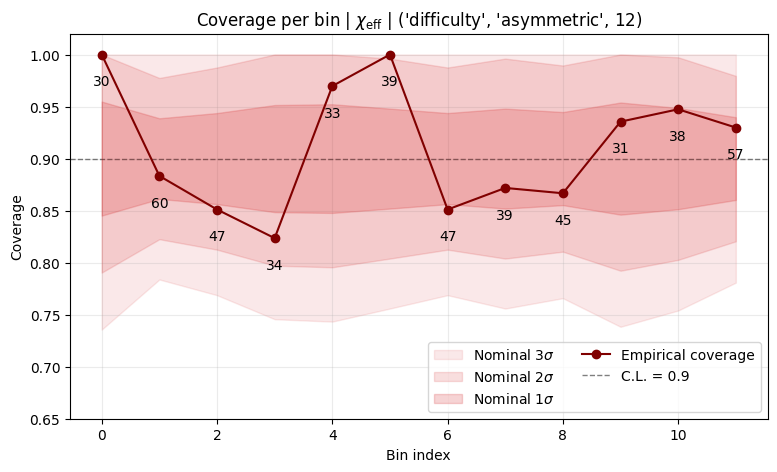

Configuration: ('difficulty', 'asymmetric', 8)
Label: chirp_mass

Counts per bin:
[57 43 57 82 59 57 74 71]

Coverage per bin:
[0.895 0.907 0.825 0.866 0.898 0.965 0.838 0.944]

Covered count per bin:
[51 39 47 71 53 55 62 67]

Bin undercoverage p-values:
[0.5112 0.6352 0.0548 0.1943 0.5459 0.9819 0.0631 0.9335]

Lower miss rate per bin:
[0.018 0.07  0.053 0.073 0.051 0.035 0.149 0.028]

Upper miss rate per bin:
[0.088 0.023 0.123 0.061 0.051 0.    0.014 0.028]

Interval offsets per bin:
[[-0.6167  0.4852]
 [-0.5072  0.8528]
 [-1.0026  1.0376]
 [-1.3532  1.2293]
 [-1.2342  1.2055]
 [-1.1109  1.4229]
 [-0.9917  1.2587]
 [-1.2378  1.4651]]

Calibrator bin counts:
[63 62 63 62 62 63 62 63]

Quantile indices:
[[ 3 60]
 [ 3 59]
 [ 3 60]
 [ 3 59]
 [ 3 59]
 [ 3 60]
 [ 3 59]
 [ 3 60]]


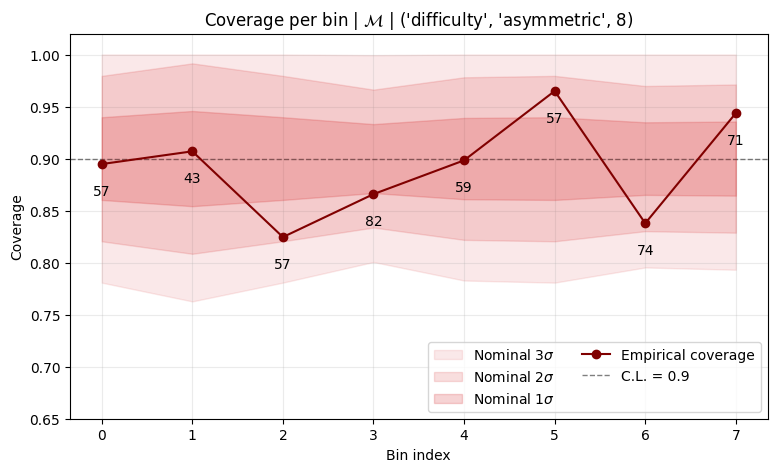

Configuration: ('difficulty', 'symmetric', 6)
Label: total_mass

Counts per bin:
[ 77  80  70  84 104  85]

Coverage per bin:
[0.87  0.862 0.871 0.905 0.971 0.906]

Covered count per bin:
[ 67  69  61  76 101  77]

Bin undercoverage p-values:
[0.2385 0.1734 0.2637 0.6111 0.9986 0.6247]

Lower miss rate per bin:
[0.039 0.062 0.029 0.024 0.029 0.012]

Upper miss rate per bin:
[0.091 0.075 0.1   0.071 0.    0.082]

Interval offsets per bin:
[[-0.9817  0.9817]
 [-0.8995  0.8995]
 [-0.9924  0.9924]
 [-0.9973  0.9973]
 [-1.2155  1.2155]
 [-1.1262  1.1262]]

Calibrator bin counts:
[84 83 83 83 83 84]

Quantile indices:
[[76 76]
 [75 75]
 [75 75]
 [75 75]
 [75 75]
 [76 76]]


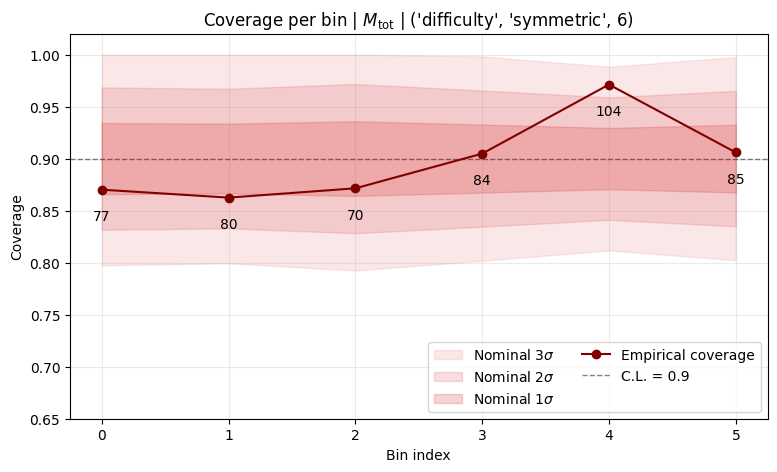

In [19]:


for row in best_by_label.itertuples():
    key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
    label_idx = row.label_index

    inspect_configuration(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
    )

    plot_coverage_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=confidence_level,
    )

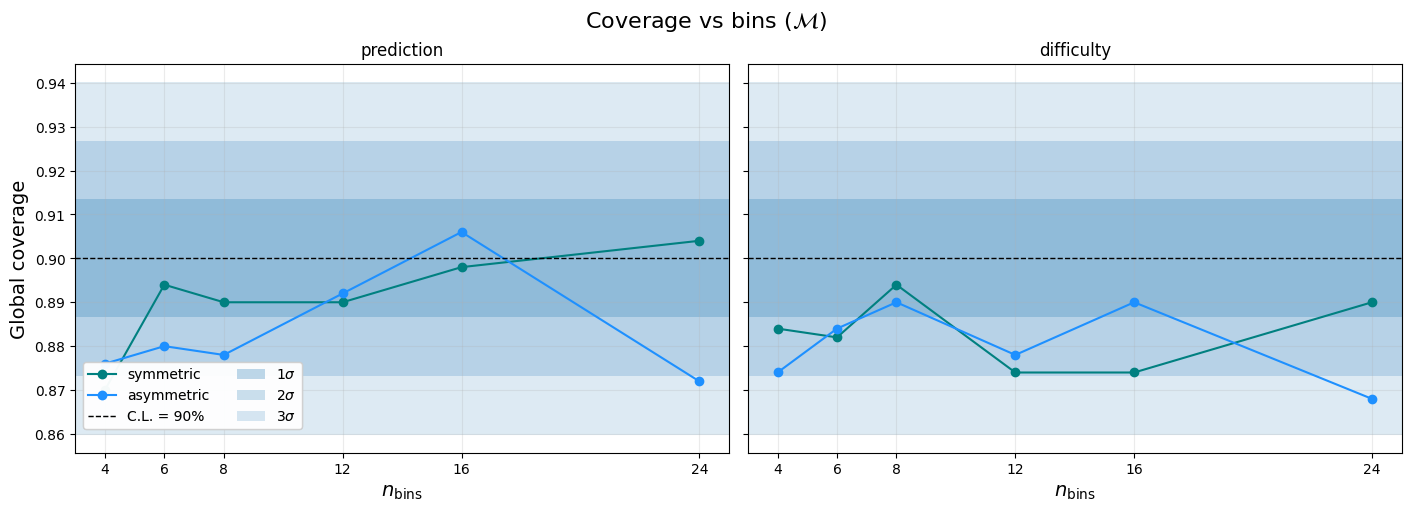

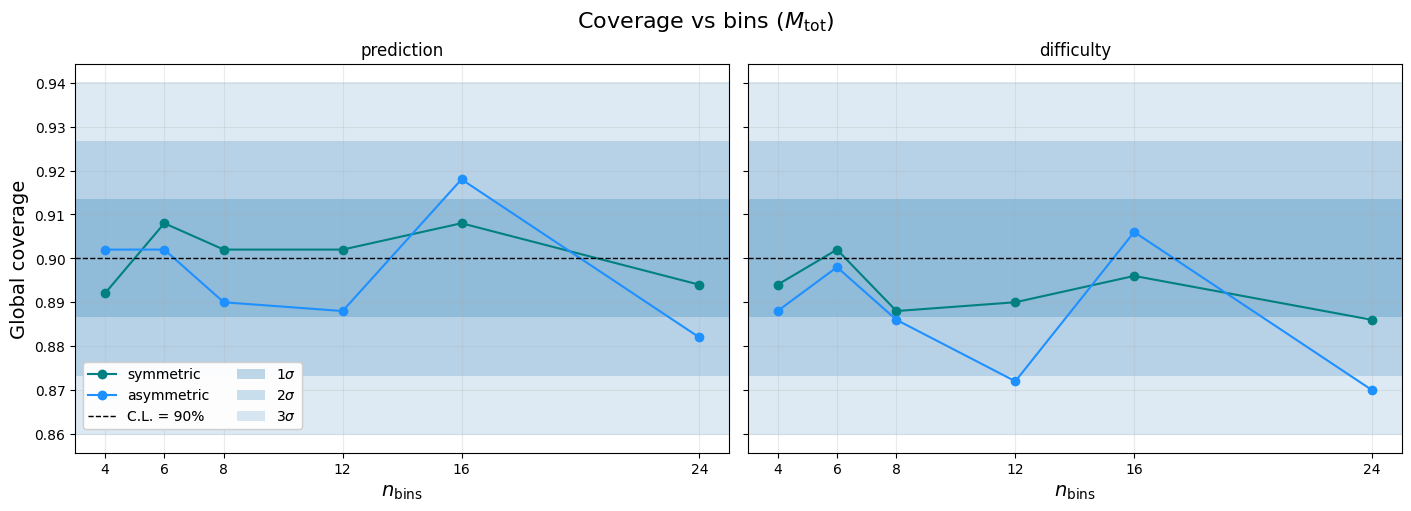

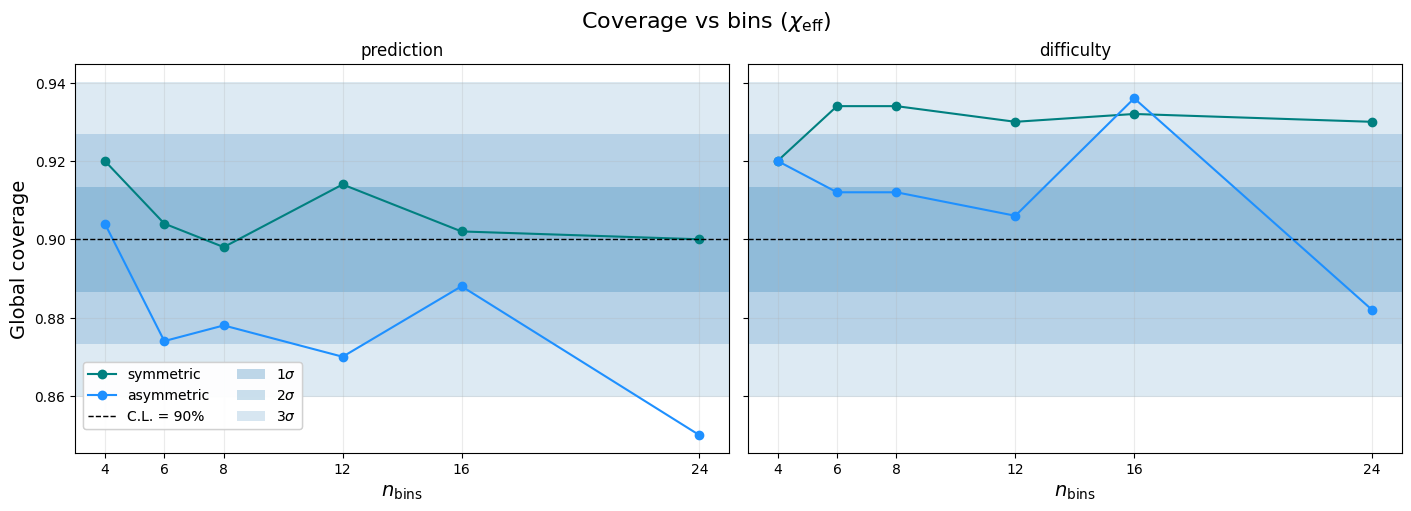

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue", 
}

for label in label_names:
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    # Por si taxonomy_modes tuviera longitud 1
    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=plot_colors[interval_mode],
            )

        # Tolerancias globales: para este label, n debería ser constante
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level*100)}%",
        )

        ax.axhspan(low_1, high_1, alpha=0.25, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, alpha=0.20, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, alpha=0.15, label=r"$3\sigma$")
        

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=14)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

        handles, labels_legend = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels_legend,
            loc="upper left",
            bbox_to_anchor=(0.05, 0.30),
            ncol=2,
        )

    axes[0].set_ylabel("Global coverage", fontsize=14)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    

    plt.show()

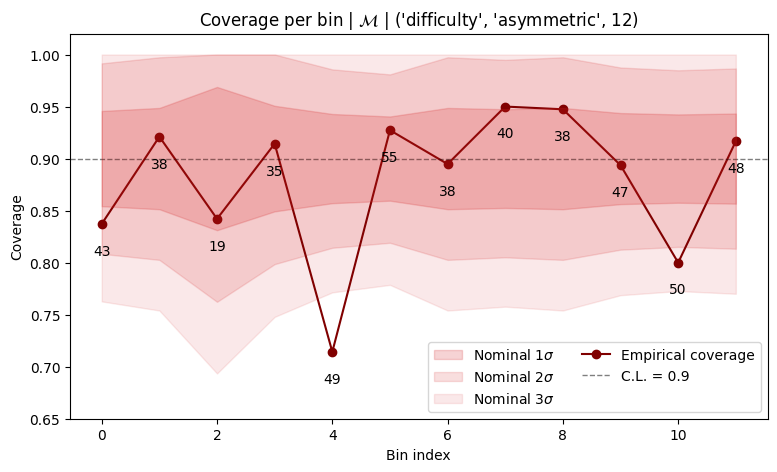

In [21]:
key = ("difficulty", "asymmetric", 12)
result = all_results[key]
metrics = result.metrics

label_idx = 0
label = label_names[label_idx]

coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
counts_per_bin = metrics["counts_per_bin"][:, label_idx]
bin_tol = metrics["bin_tolerance_normal"]

x = np.arange(len(coverage_per_bin))

low_1 = bin_tol["1sigma_low"][:, label_idx]
low_2 = bin_tol["2sigma_low"][:, label_idx]
low_3 = bin_tol["3sigma_low"][:, label_idx]
high_1 = bin_tol["1sigma_high"][:, label_idx]
high_2 = bin_tol["2sigma_high"][:, label_idx] 

high_3 = bin_tol["3sigma_high"][:, label_idx]

band_color = "tab:red"

plt.figure(figsize=(9, 5))


plt.fill_between(x, low_1, high_1, color=band_color, alpha=0.20, label=r"Nominal 1$\sigma$", zorder=3)
plt.fill_between(x, low_2, high_2, color=band_color, alpha=0.15, label=r"Nominal 2$\sigma$", zorder=2)
plt.fill_between(x, low_3, high_3, color=band_color, alpha=0.10, label=r"Nominal 3$\sigma$", zorder=1)
plt.plot(x, coverage_per_bin, marker="o", color="maroon", label="Empirical coverage" )
plt.axhline(confidence_level, linestyle="--", alpha=0.5, linewidth=1.0, color="black", label=rf"C.L. = {confidence_level}")

for i, n in enumerate(counts_per_bin):
    plt.text(i, coverage_per_bin[i] - 0.03, str(n), ha="center", fontsize=10, color="k")

plt.xlabel("Bin index")
plt.ylabel("Coverage")
plt.title(f"Coverage per bin | {plot_labels[label]} | {key}")
plt.ylim(0.65, 1.02)
plt.legend(ncols=2, loc="lower right")
plt.show()